###**Importing Libraries**

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

###**Setting Visualization Style**

In [2]:
# Setting visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

###**Importing Data**

In [3]:
from google.colab import files
uploaded = files.upload()

# Load all the analysis results
transactions = pd.read_csv('online_retail_cleaned.csv')
customer_clusters = pd.read_csv('customer_clusters.csv')
churn_prediction = pd.read_csv('churn_prediction.csv')
customer_lifetime_value = pd.read_csv('customer_lifetime_value.csv')


Saving online_retail_cleaned.csv to online_retail_cleaned.csv
Saving churn_prediction.csv to churn_prediction.csv
Saving customer_clusters.csv to customer_clusters.csv
Saving customer_lifetime_value.csv to customer_lifetime_value.csv


###**Data Type Conversion**

In [7]:
# Convert date columns to datetime
transactions['InvoiceDate'] = pd.to_datetime(transactions['InvoiceDate'])

# Create a comprehensive customer profile dataset
customer_profile = customer_clusters.merge(
    churn_prediction[['Customer ID', 'ChurnProbability', 'ValueSegment', 'RetentionPriority']],
    on='Customer ID', how='left'
)

customer_profile = customer_profile.merge(
    customer_lifetime_value[['Customer ID', 'CLV_12_months', 'Adjusted_CLV', 'predicted_purchases']],
    on='Customer ID', how='left'
)

print(f"Compiled customer profile with {len(customer_profile)} customers")


Compiled customer profile with 4290 customers


##**Caluclating some key Business Metrics**

In [8]:
# Calculate key business metrics
total_customers = len(customer_profile)
total_revenue = transactions['TotalAmount'].sum()
average_order_value = transactions.groupby('Invoice')['TotalAmount'].sum().mean()
total_orders = transactions['Invoice'].nunique()
total_transactions = len(transactions)
items_per_order = total_transactions / total_orders

print("\n=== BUSINESS OVERVIEW ===")
print(f"Total Customers: {total_customers}")
print(f"Total Revenue: ${total_revenue:.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value: ${average_order_value:.2f}")
print(f"Average Items per Order: {items_per_order:.2f}")


=== BUSINESS OVERVIEW ===
Total Customers: 4290
Total Revenue: $6920128.64
Total Orders: 17980
Average Order Value: $384.88
Average Items per Order: 21.71


##**Create a value-risk matrix for customer segments**

In [10]:
# Create a value-risk matrix for customer segments
segment_matrix = customer_profile.groupby('Cluster_Name').agg({
    'Customer ID': 'count',
    'ChurnProbability': 'mean',
    'Adjusted_CLV': ['mean', 'sum'],
    'RetentionPriority': 'mean'
}).reset_index()

segment_matrix.columns = ['Segment', 'CustomerCount', 'ChurnRisk', 'AverageCLV', 'TotalCLV', 'RetentionPriority']
segment_matrix['CustomerPercentage'] = segment_matrix['CustomerCount'] / total_customers * 100
segment_matrix['ValuePercentage'] = segment_matrix['TotalCLV'] / segment_matrix['TotalCLV'].sum() * 100

print("\n=== CUSTOMER SEGMENT OVERVIEW ===")
display(segment_matrix[['Segment', 'CustomerCount', 'CustomerPercentage', 'ChurnRisk', 'AverageCLV', 'ValuePercentage']])


=== CUSTOMER SEGMENT OVERVIEW ===


,Segment,CustomerCount,CustomerPercentage,ChurnRisk,AverageCLV,ValuePercentage
0,High-Value Active Customers,233,5.431235,0.021988,9759.073527,42.229304
1,Inactive Customers,4057,94.568765,0.476951,1238.829298,57.770696


##**Create a value-risk quadrant visualization**

In [14]:
# Create a value-risk quadrant visualization
fig = px.scatter(
    segment_matrix,
    x='ChurnRisk',
    y='AverageCLV',
    size='CustomerCount',
    color='Segment',
    text='Segment',
    hover_data=['CustomerPercentage', 'ValuePercentage'],
    title='Customer Segment Value-Risk Matrix'
)


fig.update_layout(
    xaxis_title='Churn Risk',
    yaxis_title='Average CLV (12 months)',
    xaxis=dict(range=[0, 1]),
    annotations=[
        dict(
            x=0.25, y=1.1 * segment_matrix['AverageCLV'].max(),  # Dynamic y-coordinate for annotation
            text="Low Risk, High Value<br>(Nurture & Grow)",
            showarrow=False,
            font=dict(size=12)
        ),
        dict(
            x=0.75, y=1.1 * segment_matrix['AverageCLV'].max(),  # Dynamic y-coordinate for annotation
            text="High Risk, High Value<br>(Urgent Retention)",
            showarrow=False,
            font=dict(size=12)
        ),
        dict(
            x=0.25, y=0.1 * segment_matrix['AverageCLV'].max(),   # Dynamic y-coordinate for annotation #Changed to range[0] for bottom positioning
            text="Low Risk, Low Value<br>(Maintain)",
            showarrow=False,
            font=dict(size=12)
        ),
        dict(
            x=0.75, y=0.1 * segment_matrix['AverageCLV'].max(),  # Dynamic y-coordinate for annotation #Changed to range[0] for bottom positioning
            text="High Risk, Low Value<br>(Selective Retention)",
            showarrow=False,
            font=dict(size=12)
        )
    ],
    shapes=[
        # Vertical line
        dict(
            type="line", xref="x", yref="paper",
            x0=0.5, y0=0, x1=0.5, y1=1,
            line=dict(color="Black", width=1, dash="dash")
        ),
        # Horizontal line
        dict(
            type="line", xref="paper", yref="y",
            x0=0, y0=segment_matrix['AverageCLV'].median(),
            x1=1, y1=segment_matrix['AverageCLV'].median(),
            line=dict(color="Black", width=1, dash="dash")
        )
    ]
)
fig.show()

 ## **Developing strategic recommendations for each segment**

In [15]:
# Develop strategic recommendations for each segment
def get_segment_strategy(row):
    if row['ChurnRisk'] < 0.5 and row['AverageCLV'] > segment_matrix['AverageCLV'].median():
        return "Nurture & Grow"
    elif row['ChurnRisk'] >= 0.5 and row['AverageCLV'] > segment_matrix['AverageCLV'].median():
        return "Urgent Retention"
    elif row['ChurnRisk'] < 0.5 and row['AverageCLV'] <= segment_matrix['AverageCLV'].median():
        return "Maintain"
    else:
        return "Selective Retention"

segment_matrix['Strategy'] = segment_matrix.apply(get_segment_strategy, axis=1)

##**Developing specific recommendations for each strategy**

In [16]:
# Develop specific recommendations for each strategy
recommendations = {
    "Nurture & Grow": [
        "Implement tiered loyalty program with exclusive benefits",
        "Create VIP early access to new products",
        "Develop personalized cross-sell recommendations",
        "Offer preferential customer service",
        "Create referral incentives"
    ],
    "Urgent Retention": [
        "Immediate personal outreach to high-value customers",
        "Develop win-back offers with meaningful incentives",
        "Implement save team with negotiation authority",
        "Create 'we miss you' campaign with personalized offers",
        "Conduct exit surveys to identify and address issues"
    ],
    "Maintain": [
        "Maintain regular engagement through standard communications",
        "Provide consistent customer experience",
        "Monitor for changes in behavior",
        "Offer occasional promotions to maintain engagement",
        "Look for cost-effective upsell opportunities"
    ],
    "Selective Retention": [
        "Implement targeted, low-cost retention campaigns",
        "Automate re-engagement efforts",
        "Focus on digital self-service to reduce costs",
        "Test targeted offers on selected sub-segments",
        "Identify highest potential customers within this segment for focused efforts"
    ]
}

##**Displaying recommendations by strategy**

In [17]:
# Display recommendations by strategy
print("\n=== STRATEGIC RECOMMENDATIONS BY SEGMENT ===")
for strategy in recommendations:
    print(f"\n{strategy} Strategy:")
    segments = segment_matrix[segment_matrix['Strategy'] == strategy]['Segment'].tolist()
    print(f"Applicable to: {', '.join(segments)}")
    print(f"Recommendations:")
    for i, rec in enumerate(recommendations[strategy], 1):
        print(f"  {i}. {rec}")

# Calculate potential impact of recommendations
churn_reduction_rate = {
    "Nurture & Grow": 0.1,  # 10% reduction in churn rate
    "Urgent Retention": 0.25,  # 25% reduction in churn rate
    "Maintain": 0.05,  # 5% reduction in churn rate
    "Selective Retention": 0.15  # 15% reduction in churn rate
}

clv_increase_rate = {
    "Nurture & Grow": 0.15,  # 15% increase in CLV
    "Urgent Retention": 0.05,  # 5% increase in CLV
    "Maintain": 0.02,  # 2% increase in CLV
    "Selective Retention": 0.01  # 1% increase in CLV
}



=== STRATEGIC RECOMMENDATIONS BY SEGMENT ===

Nurture & Grow Strategy:
Applicable to: High-Value Active Customers
Recommendations:
  1. Implement tiered loyalty program with exclusive benefits
  2. Create VIP early access to new products
  3. Develop personalized cross-sell recommendations
  4. Offer preferential customer service
  5. Create referral incentives

Urgent Retention Strategy:
Applicable to: 
Recommendations:
  1. Immediate personal outreach to high-value customers
  2. Develop win-back offers with meaningful incentives
  3. Implement save team with negotiation authority
  4. Create 'we miss you' campaign with personalized offers
  5. Conduct exit surveys to identify and address issues

Maintain Strategy:
Applicable to: Inactive Customers
Recommendations:
  1. Maintain regular engagement through standard communications
  2. Provide consistent customer experience
  3. Monitor for changes in behavior
  4. Offer occasional promotions to maintain engagement
  5. Look for cost-

##**Calculating impact by segment**

In [18]:
# Calculate impact by segment
segment_matrix['CurrentChurnLoss'] = segment_matrix['ChurnRisk'] * segment_matrix['TotalCLV']
segment_matrix['RevisedChurnRisk'] = segment_matrix.apply(lambda x: x['ChurnRisk'] * (1 - churn_reduction_rate[x['Strategy']]), axis=1)
segment_matrix['RevisedChurnLoss'] = segment_matrix['RevisedChurnRisk'] * segment_matrix['TotalCLV']
segment_matrix['ChurnLossSaved'] = segment_matrix['CurrentChurnLoss'] - segment_matrix['RevisedChurnLoss']

segment_matrix['RevisedAverageCLV'] = segment_matrix.apply(lambda x: x['AverageCLV'] * (1 + clv_increase_rate[x['Strategy']]), axis=1)
segment_matrix['CLVIncrease'] = (segment_matrix['RevisedAverageCLV'] - segment_matrix['AverageCLV']) * segment_matrix['CustomerCount'] * (1 - segment_matrix['RevisedChurnRisk'])

segment_matrix['TotalValueImpact'] = segment_matrix['ChurnLossSaved'] + segment_matrix['CLVIncrease']
segment_matrix['ROIMultiple'] = segment_matrix['TotalValueImpact'] / (segment_matrix['CustomerCount'] * 5)  # Assuming $5 per customer implementation cost

# Display impact analysis
print("\n=== POTENTIAL IMPACT OF RECOMMENDATIONS ===")
print(f"Total Potential Value Impact: ${segment_matrix['TotalValueImpact'].sum():.2f}")
print(f"Churn-Related Savings: ${segment_matrix['ChurnLossSaved'].sum():.2f}")
print(f"CLV Increase: ${segment_matrix['CLVIncrease'].sum():.2f}")

# Display impact by segment
impact_by_segment = segment_matrix[['Segment', 'Strategy', 'CustomerCount', 'TotalValueImpact', 'ROIMultiple']]
impact_by_segment = impact_by_segment.sort_values('TotalValueImpact', ascending=False)
print("\nValue Impact by Segment:")
display(impact_by_segment)


=== POTENTIAL IMPACT OF RECOMMENDATIONS ===
Total Potential Value Impact: $468485.56
Churn-Related Savings: $79182.49
CLV Increase: $389303.07

Value Impact by Segment:


,Segment,Strategy,CustomerCount,TotalValueImpact,ROIMultiple
0,High-Value Active Customers,Nurture & Grow,233,339329.674838,291.270107
1,Inactive Customers,Maintain,4057,129155.888634,6.367064


##**Visualizing impact by segment**

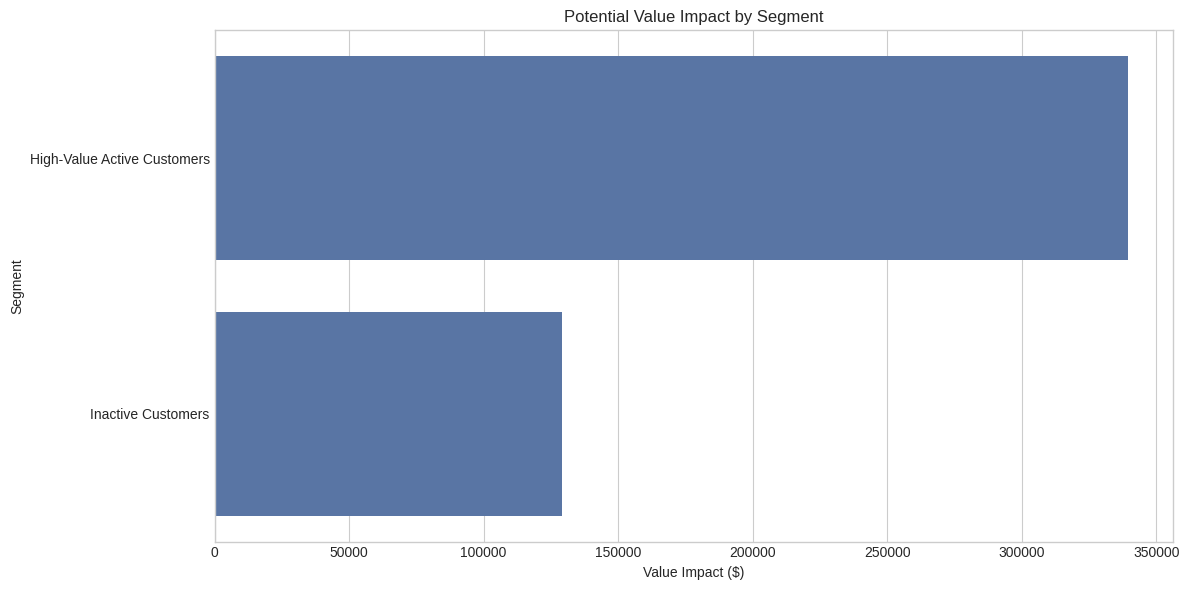

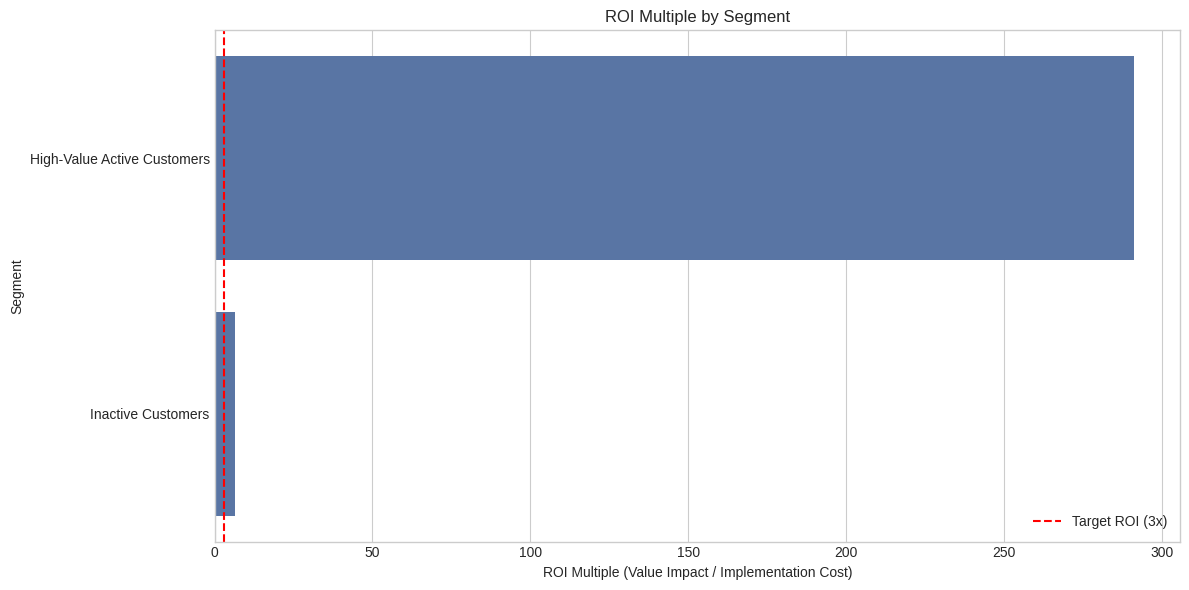

In [19]:
# Visualize impact by segment
plt.figure(figsize=(12, 6))
sns.barplot(x='TotalValueImpact', y='Segment', data=impact_by_segment)
plt.title('Potential Value Impact by Segment')
plt.xlabel('Value Impact ($)')
plt.tight_layout()
plt.show()

# Visualize ROI multiple by segment
plt.figure(figsize=(12, 6))
sns.barplot(x='ROIMultiple', y='Segment', data=impact_by_segment)
plt.title('ROI Multiple by Segment')
plt.xlabel('ROI Multiple (Value Impact / Implementation Cost)')
plt.axvline(x=3, color='red', linestyle='--', label='Target ROI (3x)')
plt.legend()
plt.tight_layout()
plt.show()

##**IMPLEMENTATION ROADMAP**

Phase 1: Quick Wins (1-2 months)
  1. Begin immediate outreach to high-risk, high-value customers
  2. Implement basic loyalty recognition for top-tier customers
  3. Launch re-engagement email campaigns for churned customers
  4. Set up basic monitoring dashboards for key customer metrics

Phase 2: Strategic Initiatives (3-6 months)
  1. Launch comprehensive tiered loyalty program
  2. Implement personalized product recommendation engine
  3. Develop customer health scoring system
  4. Create segment-specific marketing automation workflows
  5. Implement regular customer feedback collection

Phase 3: Advanced Optimization (7-12 months)
  1. Implement predictive churn model with real-time alerts
  2. Develop advanced CLV optimization strategies
  3. Create dynamic pricing/offer personalization
  4. Implement multi-channel engagement orchestration
  5. Deploy advanced customer analytics dashboard


##**KEY PERFORMANCE INDICATORS**##

Customer Retention KPIs:
  1. Churn rate by segment
  2. Retention rate after intervention
  3. Win-back rate for churned customers
  4. Customer lifetime duration

Customer Value KPIs:
  1. Average Customer Lifetime Value (CLV)
  2. CLV to Customer Acquisition Cost (CAC) ratio
  3. Average order value
  4. Purchase frequency
  5. Revenue per customer

Engagement KPIs:
  1. Program participation rates
  2. Email open and click-through rates
  3. Repeat purchase rate
  4. Days since last purchase
  5. Net Promoter Score (NPS)

This analysis has provided a comprehensive view of our customer base through segmentation, churn prediction, and lifetime value analysis. The strategic recommendations are designed to maximize customer retention and value across different segments.

By implementing these recommendations, we can expect to:
1. Reduce overall churn rate and extend customer lifetime
2. Increase customer lifetime value through higher purchase frequency and order value
3. Improve customer satisfaction and engagement
4. Optimize marketing and retention spending for maximum ROI

The next steps are to prioritize initiatives based on impact, feasibility